<Figure size 1200x800 with 0 Axes>

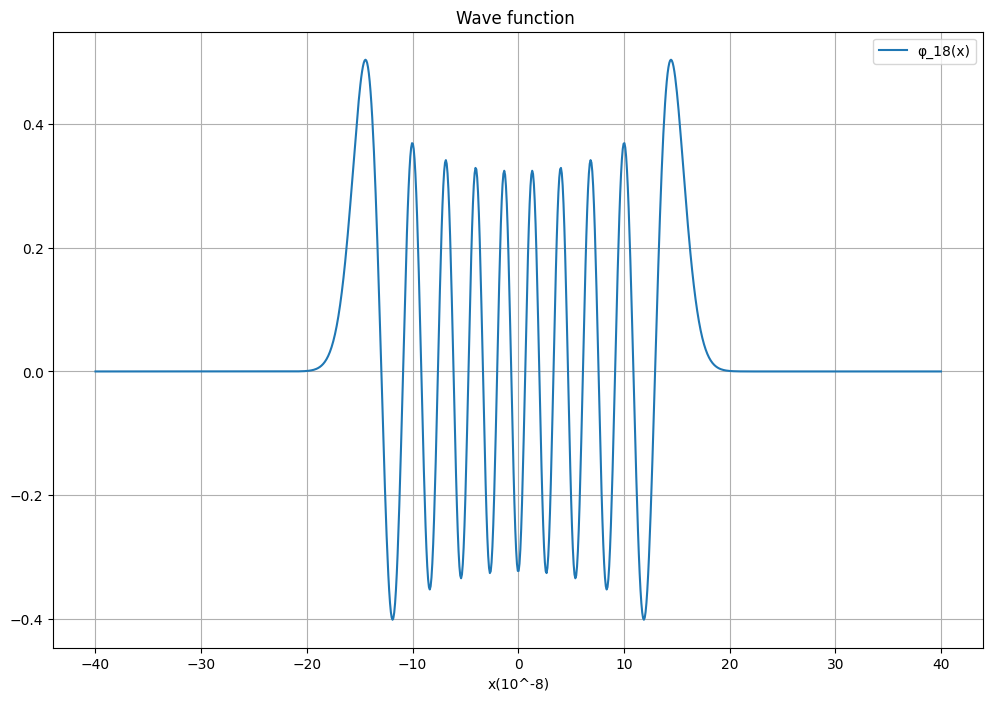

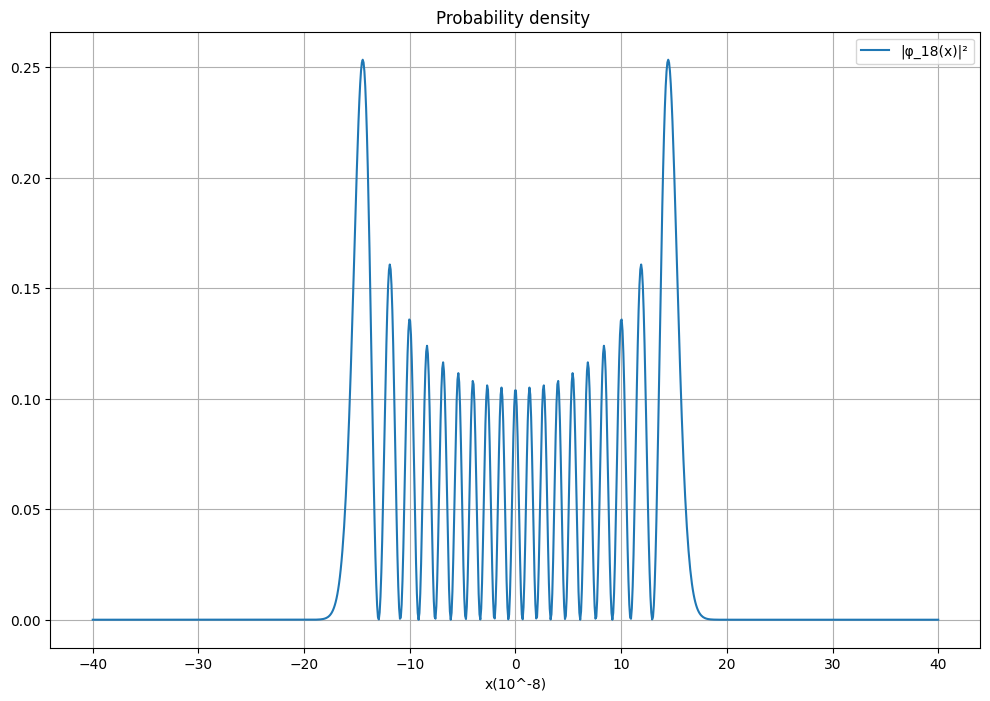

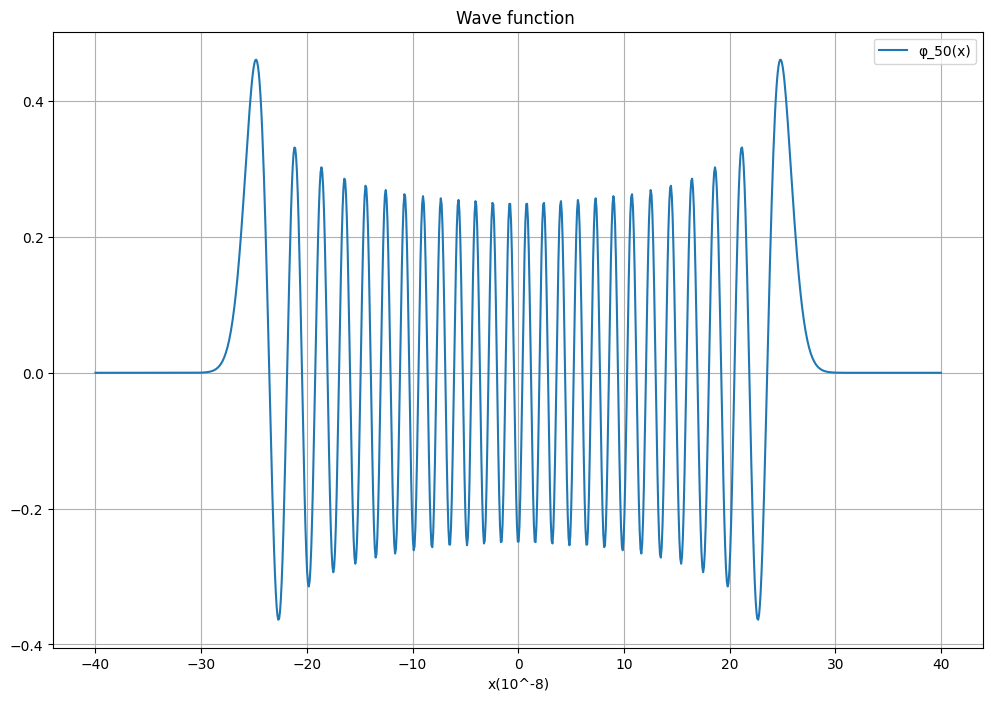

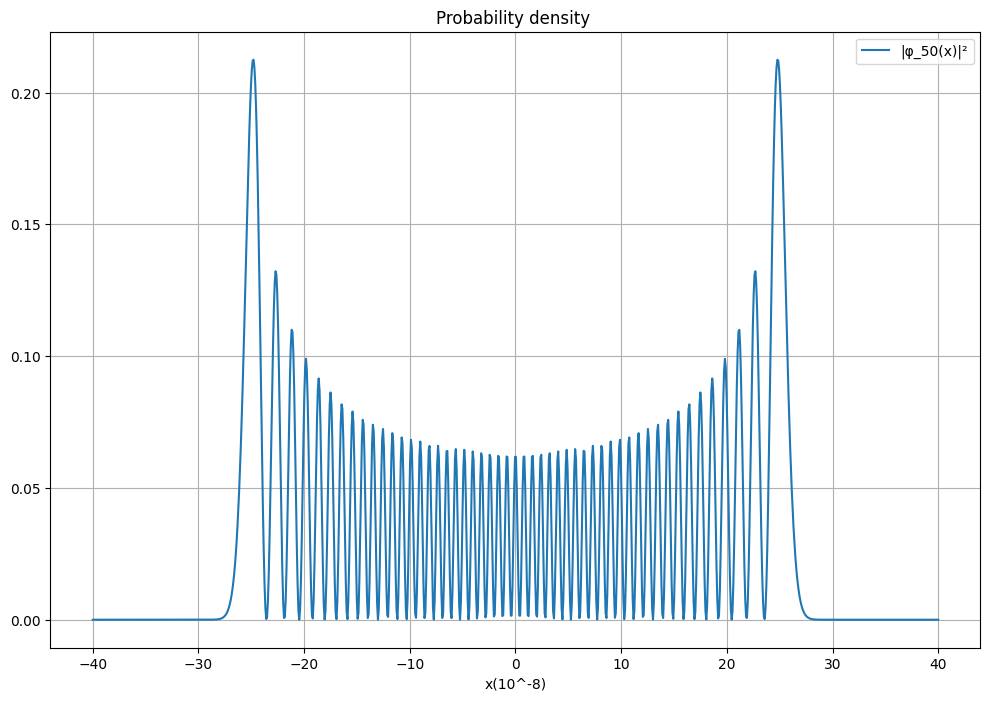

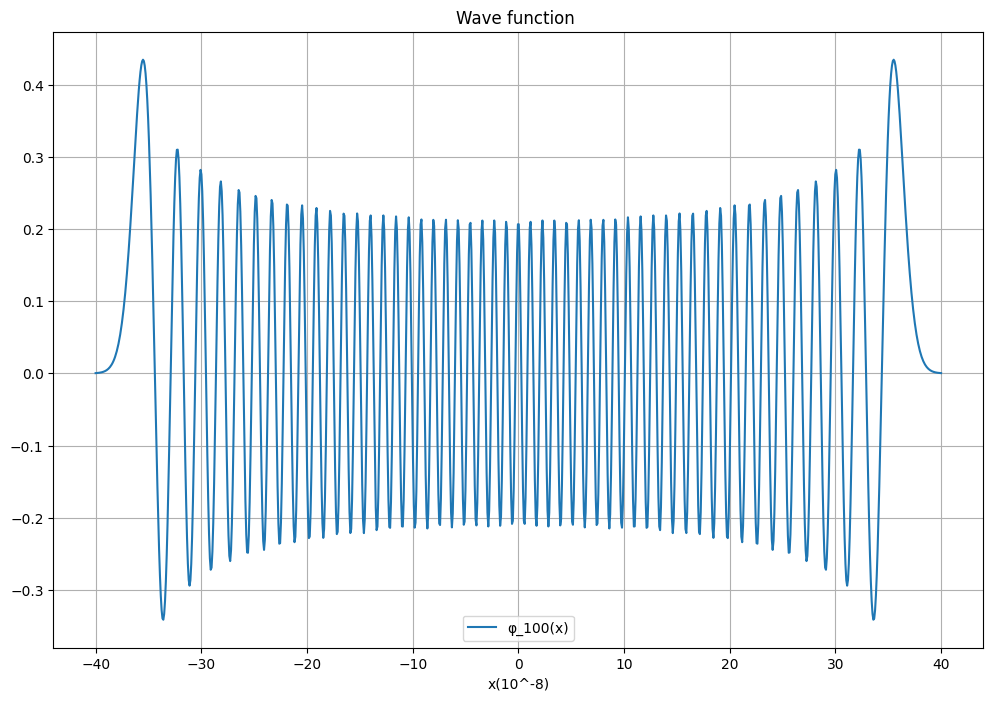

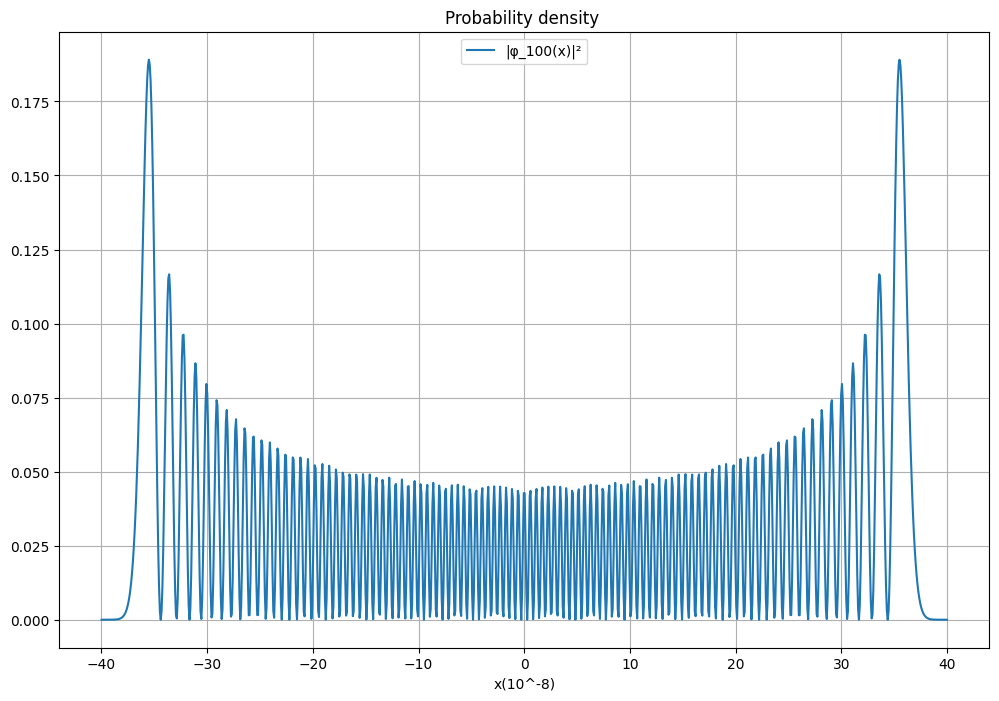

In [41]:
import numpy as np
import matplotlib.pyplot as plt

m = 9.10938356*(10**(-31))     
e= 1.602176634*(10**(-19)) 
B = 1
wc = e * B / m   # frecuencia ciclotrón
hbar = 1.054571817*(10**(-34))  # constante reducida de Planck

# Definición de variable adimensional ξ
def xi(x):
    return np.sqrt(m*wc/hbar) * x

# Funciones base del oscilador armónico cuántico
def phi0(xi):
    return (np.pi**(-0.25)) * np.exp(-xi**2/2)

def phi1(xi):
    return np.sqrt(2) * xi * phi0(xi)

# Generador de funciones de onda mediante recurrencia
def phi_n(n, xi_vals):
    if n == 0:
        return phi0(xi_vals)
    elif n == 1:
        return phi1(xi_vals)
    
    phi_nm2 = phi0(xi_vals)
    phi_nm1 = phi1(xi_vals)
    
    for k in range(2, n+1):
        phi_nk = ( np.sqrt(2/k) * ((xi_vals * phi_nm1) - np.sqrt((k-1)/2) * phi_nm2 ))
        phi_nm2, phi_nm1 = phi_nm1, phi_nk
    
    return phi_nk

lb=np.sqrt(hbar/(e*B))  # longitud de Landau

# Rango de posiciones
x_vals = np.linspace(-40, 40, 1000)
xi_vals = xi(x_vals*10**(-8))

# Niveles a graficar
n_vals = [ 18, 50, 100]

plt.figure(figsize=(12,8))

for n in n_vals:
    phi_vals = phi_n(n, xi_vals)
    prob_vals = np.abs(phi_vals)**2

    plt.figure(figsize=(12,8))
    plt.plot(x_vals, phi_vals, label=f"φ_{n}(x)")
    plt.title("Wave function ")
    plt.xlabel("x(10^-8)")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(12,8))
    plt.plot(x_vals, prob_vals, label=f"|φ_{n}(x)|²")
    plt.title("Probability density ")
    plt.xlabel("x(10^-8)")
    plt.legend()
    plt.grid()
    plt.show()



Resonance energies found (eV):
E0 = 0.3579 eV (bound state energy in the quantum well)
Transmission coefficient T = 1.0000


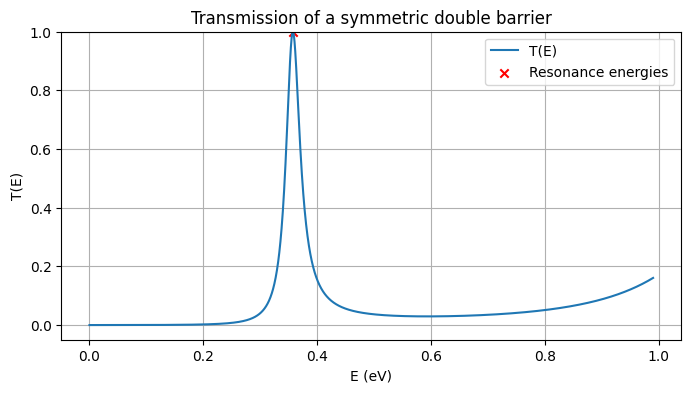

In [35]:
import numpy as np
import matplotlib.pyplot as plt

hbar = 1.054571817e-34   # J·s
eV = 1.602176634e-19     # J
m_e = 9.1093837015e-31   # kg

# We assume that the effective masses are equal to the electron mass
m_eff_gap = 1.0 * m_e
m_eff_bar = 1.0 * m_e

nm = 1e-9  

# We add +0j to avoid numerical errors for V<Ej, nevertheless the results obtained for V>Ej are not valid, as the formula of T is derived assuming E<barrier potential.
def k_from_E_V(EJ, V, mass):
    
    return np.sqrt(2 * mass * (EJ - V) / (hbar**2) +0j )

def X_from_E_V(EJ, V, mass):
    
    return np.sqrt(2 * mass * (V - EJ) / (hbar**2) +0j )


def calculate_T(k1, k3, k5, w2, w4, x2, x4, w3):
    
    phi1 = k3 * w3
    phi2 = np.arctan(x2 / k1)
    phi3 = np.arctan(x2 / k3)
    phi4 = np.arctan(x4 / k3)
    phi5 = np.arctan(x4 / k5)

    term1 = np.exp(x2 * w2 + x4 * w4) * (np.exp(1j * (-phi1 + phi2 + phi3 + phi4 + phi5)) - np.exp(1j * (phi1 + phi2 - phi3 - phi4 + phi5)))
    term2 = np.exp(x2 * w2 - x4 * w4) * (-np.exp(1j * (-phi1 + phi2 + phi3 - phi4 - phi5)) + np.exp(1j * (phi1 + phi2 - phi3 + phi4 - phi5)))
    term3 = np.exp(-x2 * w2 + x4 * w4) * (-np.exp(1j * (-phi1 - phi2 - phi3 + phi4 + phi5)) + np.exp(1j * (phi1 - phi2 + phi3 - phi4 + phi5)))
    term4 = np.exp(-x2 * w2 - x4 * w4) * (np.exp(1j * (-phi1 - phi2 - phi3 - phi4 - phi5)) - np.exp(1j * (phi1 - phi2 + phi3 + phi4 - phi5)))

    K = term1 + term2 + term3 + term4

    numerator = (2**8) * k1 * (x2**2) * (k3**2) * (x4**2) * k5
    denominator = ((k1**2 + x2**2) * (x2**2 + k3**2) * (k3**2 + x4**2) * (x4**2 + k5**2)) * (abs(K)**2)

    T = numerator / denominator
    return np.real(T) #Again this is added to avoid numerical errors but the meaningful results are for Ej<V barrier and in that case T is always real.

# We are not adding Ej>V barrier as those are meaningless in this context (T will not be the actual value).
Emin, Emax, nE = 0.001, 0.99, 4000
Es = np.linspace(Emin, Emax, nE)

Ts = calculate_T(
    k_from_E_V(Es * eV, 0, m_eff_gap),
    k_from_E_V(Es * eV, 0, m_eff_gap),
    k_from_E_V(Es * eV, 0, m_eff_gap),
    0.4 * nm,  # first barrier width
    0.4 * nm,  # second barrier width
    X_from_E_V(Es * eV, 1 * eV, m_eff_bar),
    X_from_E_V(Es * eV, 1 * eV, m_eff_bar),
    0.6 * nm   # well width
)


peaks_idx = []
for i in range(2, len(Ts) - 2):
    if Ts[i] > Ts[i-1] and Ts[i] > Ts[i+1] and Ts[i] > 0.01:
        peaks_idx.append(i)

peak_energies = Es[peaks_idx]

print("Resonance energies found (eV):")
for e in peak_energies:
    Tpeak= calculate_T(
    k_from_E_V(e * eV, 0, m_eff_gap),
    k_from_E_V(e * eV, 0, m_eff_gap),
    k_from_E_V(e * eV, 0, m_eff_gap),
    0.4 * nm,  # first barrier width
    0.4 * nm,  # second barrier width
    X_from_E_V(e * eV, 1 * eV, m_eff_bar),
    X_from_E_V(e * eV, 1 * eV, m_eff_bar),
    0.6 * nm   # well width
)
    print(f"E0 = {e:.4f} eV (bound state energy in the quantum well)")
    print(f"Transmission coefficient T = {Tpeak:.4f}")
    

plt.figure(figsize=(8, 4))
plt.plot(Es, Ts, label="T(E)")
plt.xlabel("E (eV)")
plt.ylabel("T(E)")
plt.title("Transmission of a symmetric double barrier")
plt.ylim(-0.05, 1.0)
plt.grid(True)
plt.scatter(Es[peaks_idx], Ts[peaks_idx], marker='x', color='red', label="Resonance energies")
plt.legend()
plt.show()


Resonance energies found (eV):
E0 = 0.1869 eV
Transmission coefficient T = 0.3262


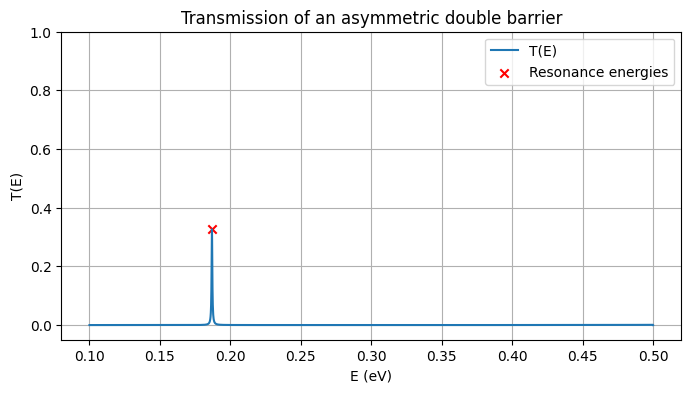

In [38]:
# We are not adding Ej>V first barrier (minimum V barrier value) as those are meaningless in this context (T will not be the actual value).
Emin, Emax, nE = 0.1, 0.5, 4000
Es = np.linspace(Emin, Emax, nE)
#In this case, we only get reasonable results for m=m_eff insted of m=m_e.
m_eff_gap = 0.067 * m_e
m_eff_bar = 0.067 * m_e

V_bar1 = 0.5 * eV  
V_bar2 = 1.13 * eV  

Ts = calculate_T(
    k_from_E_V(Es * eV, 0, m_eff_gap),      # k1: left region
    k_from_E_V(Es * eV, 0, m_eff_gap),      # k3: well
    k_from_E_V(Es * eV, 0, m_eff_gap),      # k5: right region
    4.0 * nm,                               # w2: first barrier width
    3.0 * nm,                               # w4: second barrier width
    X_from_E_V(Es * eV, V_bar1, m_eff_bar), # x2: first barrier
    X_from_E_V(Es * eV, V_bar2, m_eff_bar), # x4: second barrier
    3.6 * nm                                # w3: well width
)


peaks_idx = []
for i in range(2, len(Ts) - 2):
    if Ts[i] > Ts[i-1] and Ts[i] > Ts[i+1] and Ts[i] > 0.01:
        peaks_idx.append(i)

peak_energies = Es[peaks_idx]

print("Resonance energies found (eV):")
for e in peak_energies:
    Tpeak= calculate_T(
    k_from_E_V(e * eV, 0, m_eff_gap),      # k1: left region
    k_from_E_V(e * eV, 0, m_eff_gap),      # k3: well
    k_from_E_V(e * eV, 0, m_eff_gap),      # k5: right region
    4.0 * nm,                               # w2: first barrier width
    3.0 * nm,                               # w4: second barrier width
    X_from_E_V(e * eV, V_bar1, m_eff_bar), # x2: first barrier
    X_from_E_V(e * eV, V_bar2, m_eff_bar), # x4: second barrier
    3.6 * nm                                # w3: well width
)
    print(f"E0 = {e:.4f} eV")
    print(f"Transmission coefficient T = {Tpeak:.4f}")
    

plt.figure(figsize=(8, 4))
plt.plot(Es, Ts, label="T(E)")
plt.xlabel("E (eV)")
plt.ylabel("T(E)")
plt.title("Transmission of an asymmetric double barrier")
plt.ylim(-0.05, 1.0)
plt.grid(True)
plt.scatter(Es[peaks_idx], Ts[peaks_idx], marker='x', color='red', label="Resonance energies")
plt.legend()
plt.show()


I will use the average values of potential for each barrier and the well(left region: 0eV, well: -0.3432eV, right region: -0.63eV, first barrier: 0.3856eV, second barrier: 0.5866eV)
Resonance energies found(eV):
E0 = 0.2754 eV 
Transmission coefficient T = 0.8898


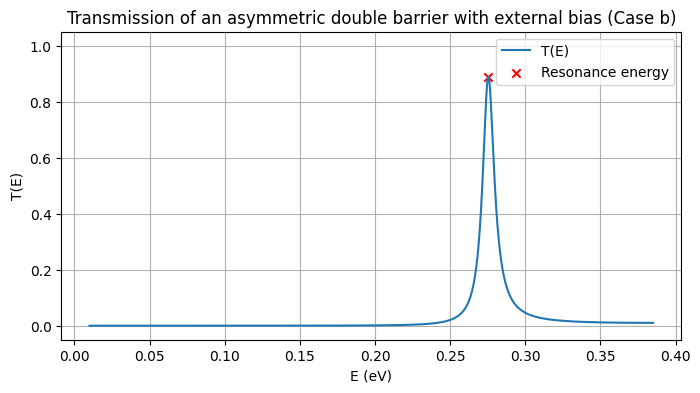

In [40]:
print('I will use the average values of potential for each barrier and the well(left region: 0eV, well: -0.3432eV, right region: -0.63eV, first barrier: 0.3856eV, second barrier: 0.5866eV)')
# We are not adding Ej>V first barrier (minimum V barrier value) as those are meaningless in this context (T will not be the actual value).
Emin, Emax, nE = 0.01, 0.385, 4000
Es = np.linspace(Emin, Emax, nE)

m_eff_gap = 0.067 * m_e
m_eff_bar = 0.067 * m_e

Ts = calculate_T(
    k_from_E_V(Es* eV, 0, m_eff_gap),          # k1: left region
    k_from_E_V(Es* eV, -0.3432*eV, m_eff_gap), # k3: well
    k_from_E_V(Es* eV, -0.63*eV, m_eff_gap),   # k5: right region
    4*nm,                                      # w2: first barrier width
    3*nm,                                      # w4: second barrier width
    X_from_E_V(Es* eV, 0.3856*eV, m_eff_bar),  # x2: first barrier
    X_from_E_V(Es* eV, 0.5866*eV, m_eff_bar),  # x4: second barrier
    4*nm                                       # w3: well width
)

peaks_idx = []
for i in range(2, len(Ts)-2):
    if Ts[i] > Ts[i-1] and Ts[i] > Ts[i+1] and Ts[i] > 0.01:
        peaks_idx.append(i)
peak_energies = Es[peaks_idx]

print("Resonance energies found(eV):")
for e in peak_energies:
    Tpeak=calculate_T(
    k_from_E_V(e* eV, 0, m_eff_gap),          # k1: left region
    k_from_E_V(e* eV, -0.3432*eV, m_eff_gap), # k3: well
    k_from_E_V(e* eV, -0.63*eV, m_eff_gap),   # k5: right region
    4*nm,                                      # w2: first barrier width
    3*nm,                                      # w4: second barrier width
    X_from_E_V(e* eV, 0.3856*eV, m_eff_bar),  # x2: first barrier
    X_from_E_V(e* eV, 0.5866*eV, m_eff_bar),  # x4: second barrier
    4*nm ) 
    print(f"E0 = {e:.4f} eV ")
    print(f"Transmission coefficient T = {Tpeak:.4f}")
    

plt.figure(figsize=(8,4))
plt.plot(Es, Ts, label="T(E)")
plt.xlabel("E (eV)")
plt.ylabel("T(E)")
plt.title("Transmission of an asymmetric double barrier with external bias (Case b)")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.scatter(Es[peaks_idx], Ts[peaks_idx], marker='x', color='red', label="Resonance energy")
plt.legend()
plt.show()
